# Analyze chemical properties
From steps 0 to 2, we were able to train a chemprop model using two columns:
- structure (SMILES)
- pChEMBL value

ML is great because it relies on pattern recogniction to make predictions based on compound structure we feed it. The issue is, pattern recognition does not replace the knowledge of an experienced chemist.

So now, let's take a step back and really analyze chemical properties of the compounds in our training/testing dataset that we gathered from step 0.

The specific question we are trying to answer:

**What chemical properties contribute to a higher pChEMBL value (drug potency/interactivity of TRPV1 recepter)**


In [ ]:
import pandas as pd

In [ ]:
# Let's get our training/testing data from step 0
train_test_data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/TRPV1-drug-discovery-research/train_test_data/trpv1_agonists_train_test_ids.csv")
train_test_data.head(5)

,molecule_chembl_id,canonical_smiles,pchembl_value
0,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.20
1,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.31
2,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,8.05
3,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.40
4,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.00


In [ ]:
!pip install chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.1 MB/s eta 0:00:00


In [ ]:
from chembl_webresource_client.new_client import new_client

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.6/36.6 MB 46.3 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem

In [ ]:
molecule = new_client.molecule
m1 = molecule.filter(chembl_id='CHEMBL17976')
m1[0]['molecule_properties']

{'alogp': '4.74',
 'aromatic_rings': 2,
 'full_molformula': 'C37H40O9',
 'full_mwt': '628.72',
 'hba': 9,
 'hbd': 2,
 'heavy_atoms': 46,
 'mw_freebase': '628.72',
 'np_likeness_score': '2.44',
 'num_ro5_violations': 1,
 'psa': '120.75',
 'qed_weighted': '0.32',
 'ro3_pass': 'N',
 'rtb': 8}

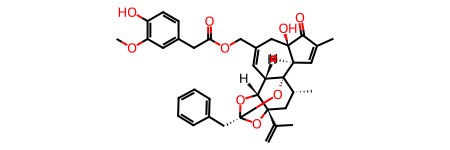

In [ ]:
# Visualize RTX from its molfile
rtx = Chem.MolFromMolBlock(m1[0]['molecule_structures']['molfile'])
rtx

### As you can see here, these are the molecule properties of RTX but now let's understand what they are:

https://chembl.gitbook.io/chembl-interface-documentation/frequently-asked-questions/drug-and-compound-questions

* alogp - a molecule’s lipophilicity (how well does a compound enter a fatty region/cell membrane)
* aromatic_rings - number of aromatic rings
* full_molformula - complete chemical formula of the compound
* full_mwt - full molecular weight, includes salt forms and hydrates
* hba - hydrogen bond acceptors, level of accepting a hydrogen bond
* hbd - hydrogen bond donor, level of giving up a hydrogen bond
* heavy_atoms - number of non-hydrogen atoms
* mw_freebase - core molecular weight, no salt forms or hydrates
* np_likeness_score - similarity of molecule to natural product (positive number indicates high similarity and negative number means low similarity)
* num_ro5_violations - number of rules that violate Lipinski's rule of 5 https://dev.drugbank.com/guides/terms/lipinski-s-rule-of-five:
  - No more than 5 hydrogen bond donors (hbd)
  - No more than 10 hydrogen bond acceptors (hba)
  - Molecular mass less than 500 Da (mw_freebase)
  - Partition coefficient not greater than 5 (alogp)
* psa - polar surface area
* qed_weighted - quantitative estimate of drug-likeness
* ro3_pass - rule of 3: instead of lipinski's rule of 5, its 3
* rtb - number of rotatable bonds in molecule

### Let's review the properties of RTX

* alogp - 4.74, not greater than five meets RO5
* aromatic_rings - 2
* full_molformula - C37H40O9
* full_mwt - 628.72
* hba - 9, accepts 9 hydrogen, creates bonds
* hbd - 2, donates 2 hydrogen, break bonds
* heavy_atoms - 46
* mw_freebase - 628.72 Da
* np_likeness_score - 244
* num_ro5_violations - 1, RTX violates 1 rule, it's MW is greater than 500 Da
* psa - 120.75
* qed_weighted - 0.32
* ro3_pass - N
* rtb - 8

**We will be analyzing all these properties except for full_molformula and ro3_pass as this data is not numerical.**


### There's quite a lot of factors to consider here
How can we possibly answer the question of what properties contribute to a more potent non-opioid painkiller?

**Let's consider feature selection methods!**
- Mutual information
- Distance correlation
- HSIC
- Chi-Squared Test
- Random forest
- XGBoost

### Let's visulize our data to see if it is either linear or non-linear
But first let's add chemical properties to our dataset and merge this as a new CSV file.

In [ ]:
# This will take about an hour...
chem_props = []
for i, id in enumerate(train_test_data['molecule_chembl_id'].unique()):
  m = molecule.filter(chembl_id=id)
  m_prop = m[0]['molecule_properties']
  m_prop['molecule_chembl_id'] = id
  m_prop.pop('full_molformula')
  m_prop.pop('ro3_pass')
  chem_props.append(m_prop)
  print(f"({i}/{len(train_test_data['molecule_chembl_id'].unique())}) {id}: chemical properties gathered.")

chem_props_df = pd.DataFrame(chem_props)
chem_props_df.head(5)

(0/4622)CHEMBL514691: chemical properties gathered.
(1/4622)CHEMBL4648896: chemical properties gathered.
(2/4622)CHEMBL27105: chemical properties gathered.
(3/4622)CHEMBL285922: chemical properties gathered.
(4/4622)CHEMBL17976: chemical properties gathered.
(5/4622)CHEMBL102010: chemical properties gathered.
(6/4622)CHEMBL104623: chemical properties gathered.
(7/4622)CHEMBL103590: chemical properties gathered.
(8/4622)CHEMBL102486: chemical properties gathered.
(9/4622)CHEMBL320906: chemical properties gathered.
(10/4622)CHEMBL103898: chemical properties gathered.
(11/4622)CHEMBL317045: chemical properties gathered.
(12/4622)CHEMBL321932: chemical properties gathered.
(13/4622)CHEMBL317011: chemical properties gathered.
(14/4622)CHEMBL106391: chemical properties gathered.
(15/4622)CHEMBL105252: chemical properties gathered.
(16/4622)CHEMBL104445: chemical properties gathered.
(17/4622)CHEMBL105694: chemical properties gathered.
(18/4622)CHEMBL104892: chemical properties gathered.
(19/

,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb,molecule_chembl_id
0,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0,CHEMBL514691
1,5.45,3.0,447.89,3.0,1.0,31.0,447.89,-1.51,1.0,46.92,0.56,5.0,CHEMBL4648896
2,5.03,2.0,658.82,8.0,4.0,47.0,658.82,2.12,2.0,118.84,0.14,8.0,CHEMBL27105
3,5.36,2.0,644.79,8.0,4.0,46.0,644.79,2.02,2.0,118.84,0.10,7.0,CHEMBL285922
4,4.74,2.0,628.72,9.0,2.0,46.0,628.72,2.44,1.0,120.75,0.32,8.0,CHEMBL17976


In [ ]:
merged_df = pd.merge(train_test_data, chem_props_df, on='molecule_chembl_id', how='inner')
merged_df.head(5)

,molecule_chembl_id,canonical_smiles,pchembl_value,alogp,aromatic_rings,full_mwt,hba,hbd,heavy_atoms,mw_freebase,np_likeness_score,num_ro5_violations,psa,qed_weighted,rtb
0,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.20,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
1,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.31,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
2,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,8.05,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
3,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.40,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0
4,CHEMBL514691,Cc1nc2cc(NC(=O)c3ccc(-c4ccc(F)cc4)nc3C)ccc2s1,7.00,5.37,4.0,377.44,4.0,1.0,27.0,377.44,-2.26,1.0,54.88,0.52,3.0


In [ ]:
assert False

In [ ]:
from google.colab import files

# Run this cell to download the new CSV with chemical properties data
csv_name_data = 'trpv1_agonist_data_trends.csv'
trend_data = merged_df.to_csv(csv_name_data, index=False)
files.download(csv_name_data)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>